# CSCI 4022 Spring 2026
### Final Project - Spotify Music Analysis with K-Means and Market Basket Analysis
### Katie Miller, Brooke Nelson, Brooke Seifert

---

## 1) Set up imports(numpy, pandas, etc.)

In [3]:
%pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
from sklearn.cluster import KMeans # k means 
from sklearn.metrics import silhouette_score 
from sklearn.preprocessing import StandardScaler # k means --> need to keep scaling consistent 0.1 vs 100
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict # market basket
from itertools import combinations # market basket
from mlxtend.preprocessing import TransactionEncoder # market basket
from mlxtend.frequent_patterns import apriori, association_rules # market basket

## 2) Load dataset

In [5]:
data = pd.read_csv('spotify_songs.csv')
df = pd.DataFrame(data)

## 3) Remove duplicates, data cleaning, etc.

In [6]:
df = df.dropna()
df = df.drop_duplicates()

df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


# PART I 

# K-Means: Evaluating on Tempo Danceability and Energy 

### Computing K-Means on Tempo and Danceability vs Tempo and Energy across all Playlists 

#### Completed by: Katie Miller

The goal of this portion of the project was to perform K Means clustering to observe a relationship between two pairs of variables: danceability and tempo, and energy and tempo. 

**Driving Questions**
- Does a particular song usually end up in the same cluster level for both danceability and energy?

**Methods Explained**
- WCSS: measures the sum of squared distances between each data point and its centroid
- K Means Clustering: groups similar data points into clusters without needing labeled data. It is used to uncover hidden patterns when the goal is to organize data based on similarity
    - https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/
- Elbow Method: states that the optimal k value for the number of clusters is at the "elbow" in the visualization of all of the WCSS values, or where the WCSS slows. Choosing the correct k value minimizes overfitting and helps find the maximum k value


#### Subset Dataset with just Danceability and Tempo

- The dataset was truncated to just include the variables needed for each section (danceability and tempo for the first analysis, and energy and tempo for the second analysis).
- The data was scaled in order to reduce bias towards Tempo.

In [8]:
# Danceability and Tempo
X_danceability = df[['danceability', 'tempo']].dropna() # filtering the data to just include the "Danceability" and "Tempo" columns

# Scaling the data so the values are consistent (Danceability is between 0 and 1 and Tempo is between 1 and 100)
scaler_dance = StandardScaler() # chose z score scaling to account for Euclidian Distance calculations
X_dance_scaled = scaler_dance.fit_transform(X_danceability) # https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

#### Perform K-means clustering on Danceability and Tempo

In [9]:
# Danceability and Tempo
wcss_dance = [] #creating a list of the WCSS scores for cluster amounts 1-10

# using k values of 1 - 10
buckets = range(1,10) # number of clusters
for k_value in buckets:
    kmeans = KMeans(n_clusters=k_value, random_state=42, init='k-means++', n_init=10) #from homework 2 coding portion
    kmeans.fit_transform(X_dance_scaled)
    wcss_dance.append(kmeans.inertia_)

print("WCSS values for the Danceability Data: \n", wcss_dance) #printing the WCSS values for the Danceability data (cluster amounts 1 - 10)

WCSS values for the Danceability Data: 
 [65655.99999999991, 40505.51433333003, 28469.324179953495, 22043.09599705128, 17832.42473093835, 14287.6447025402, 12192.262457174651, 10425.822111444755, 9464.173497473133]


#### Elbow Method
- After fitting and transforming the data, the Within Cluster Sum of Squares (WCSS) was computed for k cluster sizes of 1 through 10.
- The elbow method was used to pick the optimal number of clusters.

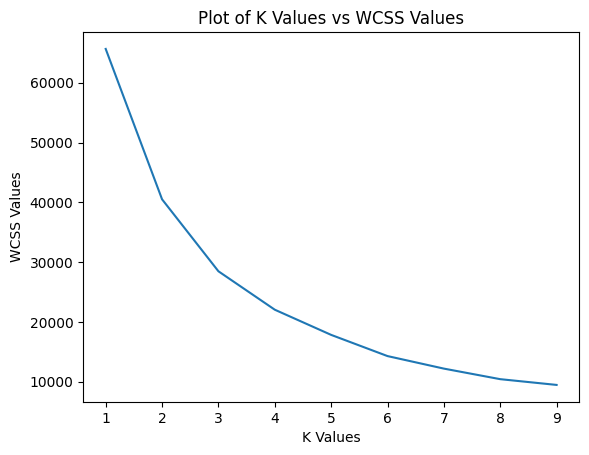

In [10]:
# Danceability and Tempo

# Elbow Method
# plot of the trend of the WCSS scores based on the number of clusters
# x axis has the k values
# y axis has the WCSS values
x_values = buckets
y_values = wcss_dance

plt.plot(x_values, y_values) 


plt.xlabel("K Values")
plt.ylabel("WCSS Values")
plt.title("Plot of K Values vs WCSS Values")

plt.show()

#### Visualize Clusters
- The cluster assignment portion of K Means was performed again after the optimal k value was chosen, and the clusters were visualized.

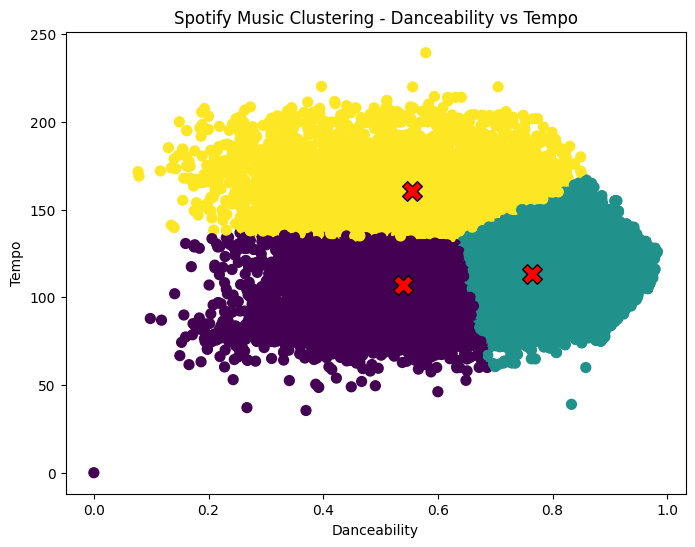

In [11]:
# Danceability and Tempo
kmeans_dance = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10) # choose number of clusters based on results from the elbow method

# Labels and Clusters
# create cluster assignments and cluster centers based on the chosen k value
labels_dance = kmeans_dance.fit_predict(X_dance_scaled)
centers_dance = kmeans_dance.cluster_centers_ 
df['dance_clusters'] = labels_dance

# Visualize Clusters
plt.figure(figsize=(8,6))
plt.scatter(df['danceability'], df['tempo'], c=df['dance_clusters'], s=50, cmap='viridis') # homework 2

unscaled_centers = scaler_dance.inverse_transform(centers_dance) # undo the scaling for visualization purposes

plt.scatter(unscaled_centers[:, 0], unscaled_centers[:, 1], marker='X', s=200, c='red', edgecolors='black')

plt.xlabel('Danceability')
plt.ylabel('Tempo')
plt.title('Spotify Music Clustering - Danceability vs Tempo')
plt.show()

#### Subset Dataset with just Danceability and Tempo

In [12]:
# Energy and Tempo
X_energy = df[['energy', 'tempo']].dropna() # filtering the data to just include the "Energy" and "Tempo" columns

# Scaling the data so the values are consistent (Energy is between 0 and 1 and Tempo is between 1 and 100)
scaler_energy = StandardScaler() # chose z score scaling to account for Euclidian Distance calculations
X_energy_scaled = scaler_energy.fit_transform(X_energy)  # https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

#### Perform K-means clustering on Energy and Tempo

In [19]:
# Energy and Tempo

wcss_energy = [] #creating a list of the WCSS scores for cluster amounts 1-10

# using k values of 1 - 10
buckets = range(1,10)  # number of clusters
for k_value in buckets:
    kmeans = KMeans(n_clusters=k_value, random_state=42, init='k-means++', n_init=10)  #from homework 2 coding portion
    kmeans.fit_transform(X_energy_scaled)
    wcss_energy.append(kmeans.inertia_)


print("WCSS values for the Energy Data: \n", wcss_energy)  #printing the WCSS values for the Energy data (cluster amounts 1 - 10)

WCSS values for the Energy Data: 
 [65656.00000000015, 41195.40866257959, 27274.13257426524, 21063.622163932094, 16448.006343204943, 13696.156176250053, 11845.044016368756, 10304.852321107846, 9252.871237138295]


#### Elbow Method

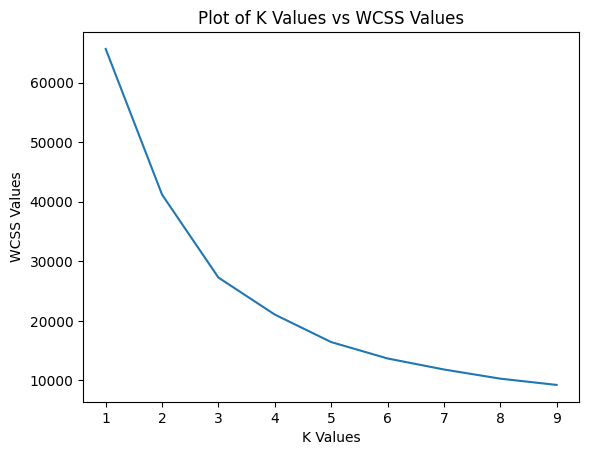

In [20]:
# Energy and Tempo

x_values_e = buckets
y_values_e = wcss_energy

plt.plot(x_values_e, y_values_e) 


plt.xlabel("K Values")
plt.ylabel("WCSS Values")
plt.title("Plot of K Values vs WCSS Values")

plt.show()

#### Visualize Clusters

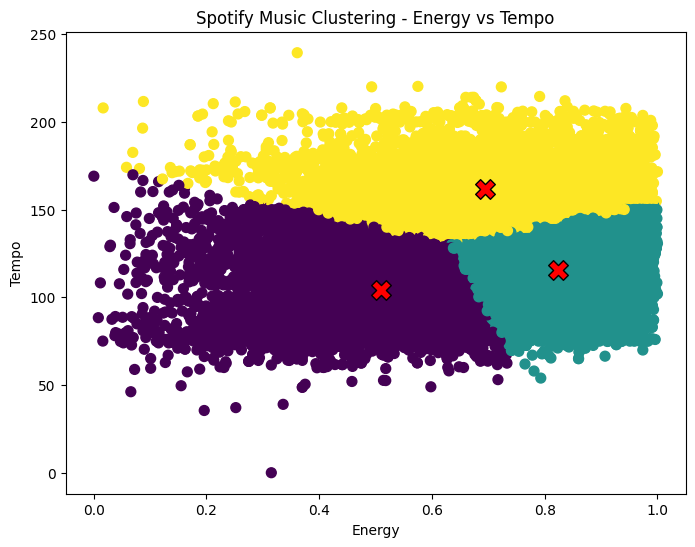

In [21]:
# Energy and Tempo
kmeans_energy = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10) # choose number of clusters based on results from the elbow method

# Labels and Clusters
# create cluster assignments and cluster centers based on the chosen k value
labels_energy = kmeans_energy.fit_predict(X_energy_scaled)
centers_energy = kmeans_energy.cluster_centers_
df['energy_clusters'] = labels_energy

# Visualize Clusters
plt.figure(figsize=(8,6))
plt.scatter(df['energy'], df['tempo'], c=df['energy_clusters'], s=50, cmap='viridis') # homework 2

unscaled_centers_e = scaler_energy.inverse_transform(centers_energy) # undo the scaling for visualization purposes

plt.scatter(unscaled_centers_e[:, 0], unscaled_centers_e[:, 1], marker='X', s=200, c='red', edgecolors='black')

plt.xlabel('Energy')
plt.ylabel('Tempo')
plt.title('Spotify Music Clustering - Energy vs Tempo')
plt.show()

### Comparison and Analysis

- After sorting the data by the cluster it was assigned to for both Danceability vs Tempo and Energy vs Tempo, the average was computed to determine cluster rankings. The findings are as follows:

  
| Cluster | Average Danceability |
| -------- | -------- |
| 0  | 0.538772  |
| 1    | 0.765059  |
| 2 | 0.554190 |

| Cluster | Average Energy |
| -------- | -------- |
| 0  | 0.509906 |
| 1    |  0.823559  |
| 2 | 0.694707 |

- Then, by comparing the total number of songs to the number of songs that match cluster rankings for both Danceability and Tempo and Energy and Tempo, the percentage of matching cluster songs can be determined. The percentage of songs that match cluster rankings for both K Means iterations is around 55% of tracks.

In [22]:
# Comparison and Analysis

print("Danceability Means")
print(df.groupby('dance_clusters')['danceability'].mean()) # groups by the danceability clusters, and then computes the mean danceability of those three clusters
# shows what the "high" cluster represents (biggest danceability)

print("\nEnergy Means")
print(df.groupby('energy_clusters')['energy'].mean()) # groups by energy clusters, and then computes the mean energy of those three clusters
# shows what the "high" cluster represents (greatest energy)

#dance clusters represents how danceable a certain song is relative to its tempo
#energy clusters represents how energetic a song is relative to its tempo

Danceability Means
dance_clusters
0    0.538772
1    0.765059
2    0.554190
Name: danceability, dtype: float64

Energy Means
energy_clusters
0    0.509906
1    0.823559
2    0.694707
Name: energy, dtype: float64


In [23]:
# comparing all songs to their clusters for both energy and danceability, how many are in the same cluster

song_count = len(df) #there are this many songs

matching_clusters = df["dance_clusters"] == df["energy_clusters"]
matching_clusters = matching_clusters.sum()

# percentage of songs matching both energy and danceability clusters
percent_matching = (matching_clusters/song_count) * 100
percent_matching = float(percent_matching)
print(f"{percent_matching:.2f}", "% are categorized in the same cluster")

55.24 % are categorized in the same cluster


### Computing K-Means on Tempo and Danceability vs Tempo and Energy Per Playlist

#### Completed by: Brooke Seifert
Use K-means to cluster playlists based on Tempo and Danceability and compare to Tempo and Energy. 

**Driving Questions**
- How many different vibes exist in a playlist in terms of Tempo and Danceability/Energy?
- How does number of clusters change based on the parameters chosen?

**Methods Explained**
- Sihouttee score: used to evalute how well fit a dataset is through similarity comparrisons
- K-Means: groups similar data points into clusters without needing labeled data

#### Tempo and Danceability

In [24]:
#creates a grouped dataframe with playlist_id and a list of track names in the dataframe, then converts to a dictionary
playlist_grouping = df.groupby('playlist_id')['track_name'].apply(list).to_dict()
#uncomment to print dictionary to see that format is playlist_id: [list of songs]
list(playlist_grouping.items())[:5]

num_playlists = len(playlist_grouping) #471 different playlists
print(num_playlists)

471


#### Choosing K-values 

Silhouette score calculates how similar a data point is to its cluster and averages this across an entire dataset to represent how well fit a set is as a whole. With 471 playlists, silhouette score was the ideal fitting process since it eliminates the need for visuallizations. Silhouette score gives a value in range -1 to 1 with 1 indicating high fit.

**Proccess:**
- Scale tempo to avoid bias and ensure interpretability 
- For each playlist calculate silhouette score for a range of values and find the maximum score
- The k associated with maximum score is saved for computation in the actual kmeans fitting


In [25]:
tempo_dance_df = df[['playlist_id','tempo', 'danceability']].groupby('playlist_id') #create dataframe of only playlist, tempo and danceability


optimal_k_dance = {}

scaler = StandardScaler() #initilize scalar, https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html


for playlist, group in tempo_dance_df: #for each playlist
    X = group[['tempo', 'danceability']].values #creates and array with tempo and danceability for each song in the playlist

    X = scaler.fit_transform(X)

    max_score = None
    max_k = None
    
    unique_X = np.unique(X, axis=0) #use np.unique to find all distinct data points 
    
    for k in range(2, min(10, len(unique_X))): #only test k-values which are under the amount of distinct data points, cannot use k greater than size of data  

        score = None
        
        kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
        kmeans.fit(X)
        
        score = silhouette_score(X, kmeans.labels_, metric='euclidean')
    
        if max_score == None or score > max_score: #account for first iteration when max_score not initialized as float
            max_score = score 
            max_k = k 
            
    optimal_k_dance[playlist] = (max_k, max_score) #add max_k and max_score to dictionary for current playlist

#### Fit the Models 

For each playlist, generate clusters with data points being songs represetned by valence and speechiness.

In [26]:
danceability_kmeans = []
for playlist, group in tempo_dance_df: 
    X = group[['tempo', 'danceability']].values

    X = scaler.fit_transform(X)

    #too small of playlists must be ignored 
    if len(X) < 2: 
        #print(len(X), playlist) #uncomment to see which playlists are getting ignored based on length
        continue
        
    kmeans = KMeans(n_clusters=optimal_k_dance[playlist][0], random_state=0, n_init="auto") #use stored optimal k value optimal_k[playlist][0]
    kmeans.fit(X)
    danceability_kmeans.append((playlist, kmeans, X)) #

#### Visualize Models

In [27]:
from scipy.spatial.distance import cdist  

#using plot_kmeans function based on "Gaussian Mixture Models & the EM Algorithm" class notes
def plot_kmeans(kmeans, X, n_clusters=4, ax=None):
    """Run K-Means and draw circular cluster boundaries."""
    labels = kmeans.labels_        #assign each point to nearest centroid
    ax = ax or plt.gca()
    ax.axis('equal')
    ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)
    plt.xlabel('Tempo')
    plt.ylabel('Danceability')
    plt.title('Danceability vs Tempo')
    centers = kmeans.cluster_centers_

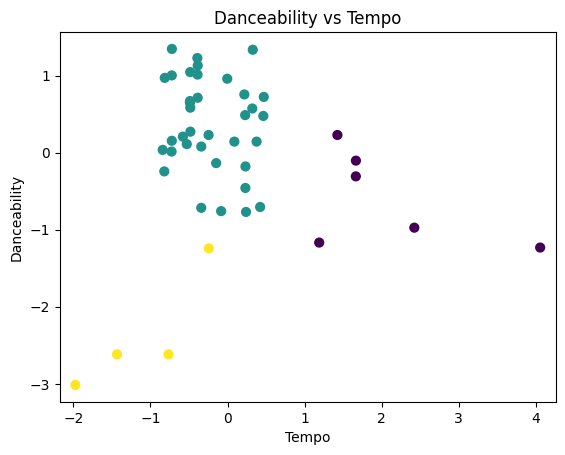

In [28]:
plot_kmeans(danceability_kmeans[3][1], danceability_kmeans[3][2])

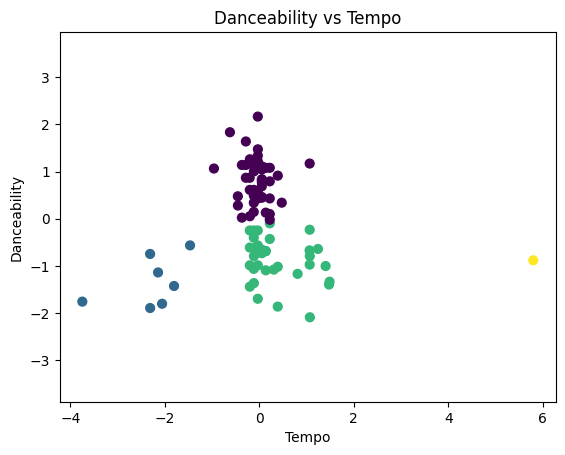

In [29]:
plot_kmeans(danceability_kmeans[100][1], danceability_kmeans[100][2])

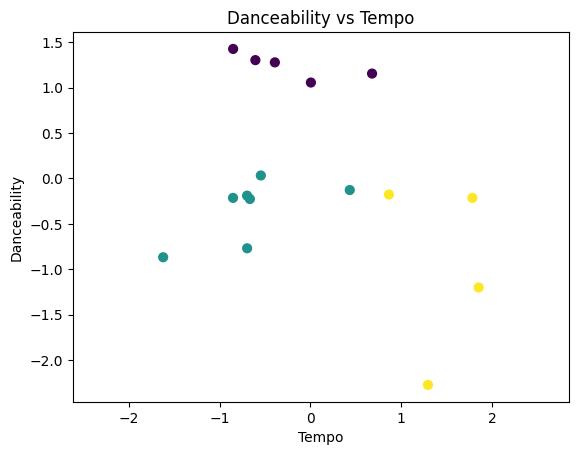

In [30]:
plot_kmeans(danceability_kmeans[200][1], danceability_kmeans[200][2])

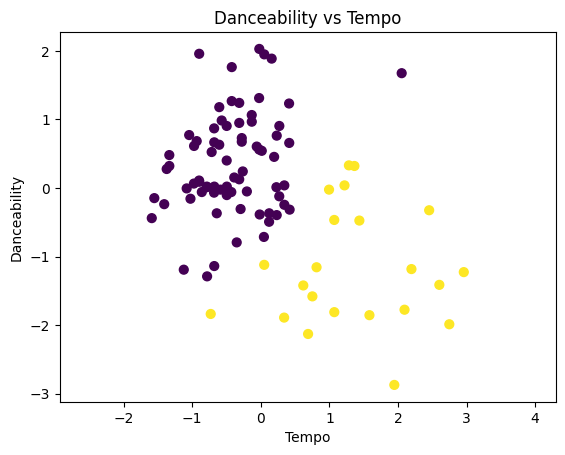

In [31]:
plot_kmeans(danceability_kmeans[461][1], danceability_kmeans[461][2])

#### Interpretations
- Calculate the average number of clusters for Tempo Vs Danceability
- Plot optimal_k vs number of songs per playlist
   - Most of the playlists have a song count in the range of 10-100, with some outliers in the range of 175-250. There is no clear association with higher song counts and higher K-values as evidenced by the scatter plot. 

In [32]:
valid_k = [] 
counts = [] 
song_counts = df.groupby('playlist_id')['track_name'].count().to_dict() #create dictionary of song counts per playlist
for playlist in optimal_k_dance: 
    k = optimal_k_dance[playlist][0]
    if k is not None: #account for playlists which might have been skipped
        valid_k.append(k)
        counts.append(song_counts[playlist])
        
avg_optimal_k_dance = sum(valid_k) / len(valid_k)

print("Average optimal k value: ", avg_optimal_k_dance)

Average optimal k value:  3.7106382978723405


Text(0.5, 1.0, 'K-values vs Song Counts: Danceability')

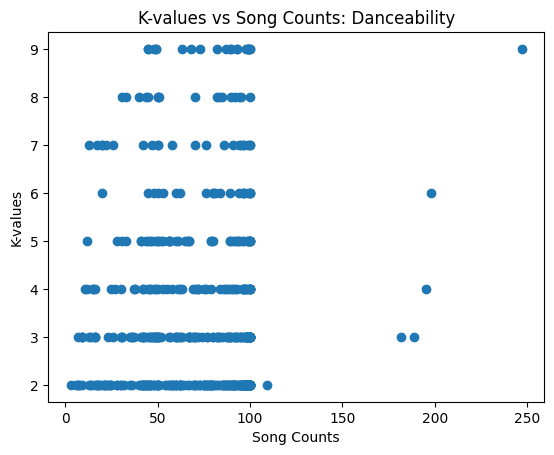

In [33]:
plt.scatter(counts, valid_k)
plt.xlabel('Song Counts')
plt.ylabel('K-values')
plt.title('K-values vs Song Counts: Danceability')

### Tempo and Energy

Following the same process as for Tempo and Danceability, now calculate based on energy.

#### Choosing K-values 

In [34]:
tempo_energy_df = df[['playlist_id','tempo', 'energy']].groupby('playlist_id')
optimal_k_energy = {}

scaler = StandardScaler() #initilize scalar


for playlist, group in tempo_energy_df: 
    X = group[['tempo', 'energy']].values

    X = scaler.fit_transform(X)

    max_score = None
    max_k = None
    
    unique_X = np.unique(X, axis=0) #accounts for issues with not enough variablity
    
    for k in range(2, min(10, len(unique_X))):

        score = None
        
        kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
        kmeans.fit(X)
        
        score = silhouette_score(X, kmeans.labels_, metric='euclidean')
    
        if max_score == None or score > max_score: #account for first iteration when max_score not initialized as float
            max_score = score 
            max_k = k 
            
    optimal_k_energy[playlist] = (max_k, max_score)

#### Fit the Model

In [35]:
energy_kmeans = []
for playlist, group in tempo_energy_df: 
    X = group[['tempo', 'energy']].values

    X = scaler.fit_transform(X)

    #too small of playlists must be ignored 
    if len(X) < 2: 
        #print(len(X), playlist) # uncomment to see which playlists are getting ignored based on length
        continue
        
    kmeans = KMeans(n_clusters=optimal_k_energy[playlist][0], random_state=0, n_init="auto") #use stored optimal k value optimal_k[playlist][0]
    kmeans.fit(X)
    energy_kmeans.append((playlist, kmeans, X))

#### Visualize the Model

In [36]:
#using plot_kmeans function based on "Gaussian Mixture Models & the EM Algorithm" class notes
def plot_kmeans(kmeans, X, n_clusters=4, ax=None):
    """Run K-Means and draw circular cluster boundaries."""
    labels = kmeans.labels_        #assign each point to nearest centroid
    ax = ax or plt.gca()
    ax.axis('equal')
    ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)
    plt.xlabel('Tempo')
    plt.ylabel('Energy')
    plt.title('Energy vs Tempo')
    centers = kmeans.cluster_centers_

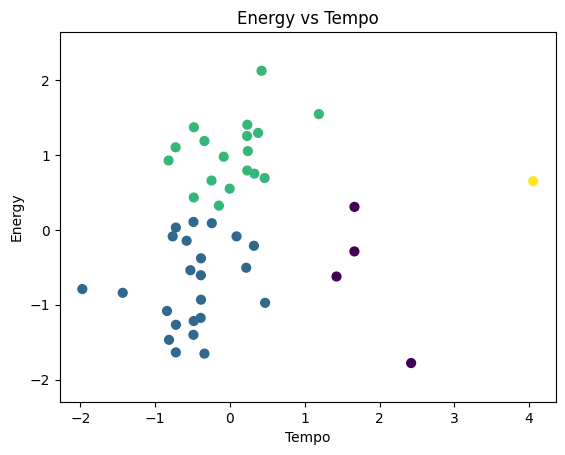

In [37]:
plot_kmeans(energy_kmeans[3][1], energy_kmeans[3][2])

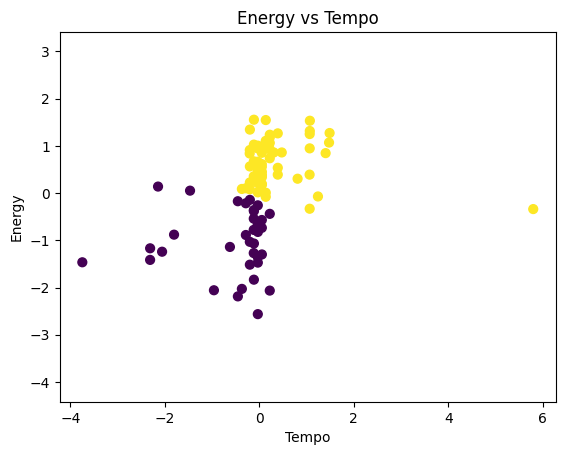

In [38]:
plot_kmeans(energy_kmeans[100][1], energy_kmeans[100][2])

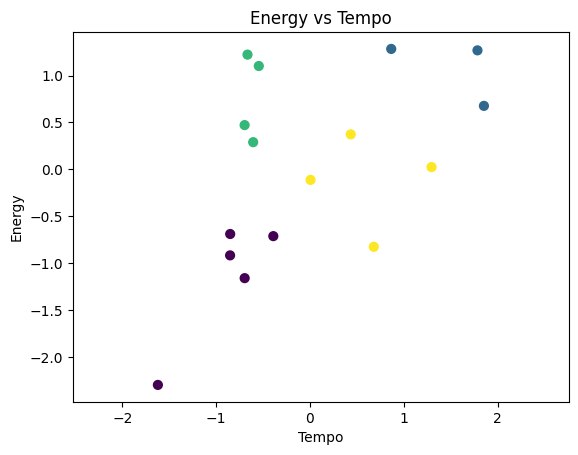

In [39]:
plot_kmeans(energy_kmeans[200][1], energy_kmeans[200][2])

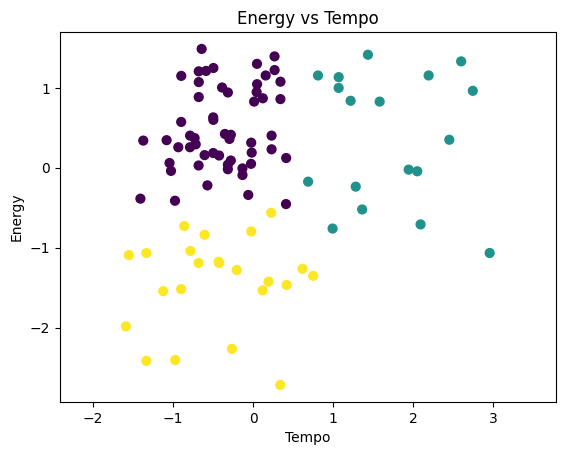

In [40]:
plot_kmeans(energy_kmeans[461][1], energy_kmeans[461][2])

#### Interpretations
- Calculate the average number of clusters for Tempo Vs Energy
- Plot optimal_k vs number of songs per playlist

In [41]:
valid_k = [] 
counts = [] 
song_counts = df.groupby('playlist_id')['track_name'].count().to_dict()
for playlist in optimal_k_energy: 
    k = optimal_k_energy[playlist][0]
    if k is not None:
        valid_k.append(k)
        counts.append(song_counts[playlist])
        
avg_optimal_k_energy= sum(valid_k) / len(valid_k)

print("Average optimal k value: ", avg_optimal_k_energy)

Average optimal k value:  4.174468085106383


Text(0.5, 1.0, 'K-values vs Song Counts: Energy')

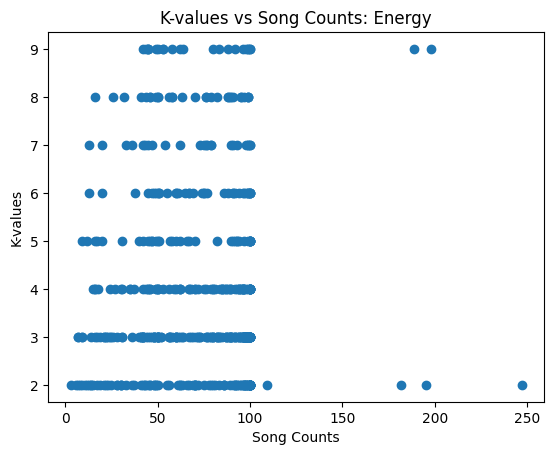

In [42]:
plt.scatter(counts, valid_k)
plt.xlabel('Song Counts')
plt.ylabel('K-values')
plt.title('K-values vs Song Counts: Energy')

### Comparison and Analysis

- After finding the optimal K-value per playlist for clustering based on Tempo and Danceability as well as Tempo and Energy, the average for each was computed. This resulted in the following:

  
| Clustering on _ | Average K-Value |
| -------- | -------- |
| Tempo and Danceability   | 3.710 |
| Tempo and Energy | 4.174 |

- This shows a slight increase in the number of optimal k-values when clustering based on Energy instead of Danceability and and average of 4 vibes existing in a playlist.

# PART II

# Market Basket Analysis: Song recommendations

#### Completed by: Brooke Nelson

Market Basket Analysis was chosen to discover songs wich frequently show up together in Spotify playlists. Each playlist was treated as a transaction and each song as a item. 

**Driving Questions**
- Which songs frequently appear together in playlists?
- Can we create meaningful song recommendation rules based on these patterns?

**Methods Explained**
- Apriori algorithim: identifies frequent itemsets using a minimum support threshold
- Association rules: connections between data points which indicate existing relationships, evaluated using confidence and lift

### Frequent itemsets using Apriori
- Convert each transaction into a frozenset.
    - This ensures that each playlist (aka transaction) acts like an unordered list, which is the type required for the Apriori algorithim.
- Minimum support of 5 is choosen because higher values excluded most song groups/song patterns and lower values included uninformative patterns



In [43]:
# Convert playlists to a list of frozensets (each playlist is a transaction)
transactions = [frozenset(tracks) for tracks in playlist_grouping.values()]

In [44]:
MIN_SUPPORT = 5

The code from homework 4 was utilized for the majority of this algorithim.

The compute_support function calculates how often each itemset occurs across all transactions. It uses the minimum support threshold set above to filter out infrequent itemset combinations.

In [45]:
def compute_support (candidates, transactions) :
    """
    Return { itemset : count } keeping only itemsets with count >= MIN_SUPPORT .
    candidates : list of frozensets
    transactions : list of frozensets
    """
    # TODO : implement
    counts = defaultdict(int)
    for t in transactions:
        for c in candidates:
            if (c.issubset(t)):
                counts[c] += 1
    return {c: cnt for c, cnt in counts.items() if cnt >= MIN_SUPPORT}

The apriori_gen function generates new candidate k-itemsets based on the found frequent (k-1)-itemsets. Both the join step, which combines itemsets, and the prune step, which removes candidates with infrequent subsets, are included.

In [46]:
def apriori_gen (prev_frequent, k) :
    """
    Generate candidate k - itemsets from frequent (k -1) - itemsets .
    Join step : combine two (k -1) - itemsets sharing their first k -2 items .
    Prune step : discard candidates whose (k -1) - subsets are not all
    frequent.
    prev_frequent : list of frozensets
    k : size of candidates to generate
    Returns a list of frozenset candidates .
    """
    # TODO : implement
    prev_sorted = sorted([sorted(fs) for fs in prev_frequent])
    prev_set    = set(prev_frequent)
    candidates  = set()

    for i in range(len(prev_sorted)):
        for j in range(i + 1, len(prev_sorted)):
            a, b = prev_sorted[i], prev_sorted[j]
            if (a[:k-2] == b[:k-2]):
                candidate = frozenset(a) | frozenset(b)
                # If len(candidate) == k and all (k-1)-subsets in prev_set
                if len(candidate) == k:
                    valid = True

                    # check every k-1 subset of the candidate
                    for subset in combinations(candidate, k-1):
                        # if any subset is not in the prev set, the candidate is not valid
                        if frozenset(subset) not in prev_set:
                            valid = False
                            break

                    # if all subsets were frequent, the candidate is valid
                    if valid:
                        candidates.add(candidate)
    return list(candidates)

The apriori function operates as the main iterative loop. It repeatedly generates and filters itemsets until no more frequent itemsets can be created.

In [47]:
# ---- Main A - Priori loop ----
def apriori_loop ( transactions , min_support ) :
    items = sorted (set(item for t in transactions for item in t))
    frequent = compute_support([frozenset([i]) for i in items], transactions)
    all_frequent = {}
    k = 1
    while frequent:
        print (f"\n === L_{k} (Frequent {k} - itemsets , min_support ={min_support }) === ")
        for fs, cnt in sorted (frequent.items(), key = lambda x : sorted (x [0])):
            print(f"{ sorted(fs) } count ={cnt} ")
        all_frequent.update(frequent)
        frequent = compute_support(apriori_gen(list(frequent.keys()), k+1), transactions)
        k += 1
    return all_frequent

In [48]:
# Run the apriori function on the transactions
frequent_itemsets = apriori_loop(transactions, MIN_SUPPORT)
print(f"\nTotal frequent itemsets found: {len(frequent_itemsets)}")


 === L_1 (Frequent 1 - itemsets , min_support =5) === 
["(Don't Fear) The Reaper"] count =6 
['10,000 Hours (with Justin Bieber)'] count =5 
['2 Of Amerikaz Most Wanted'] count =6 
['22'] count =5 
['Adicto (with Anuel AA & Ozuna)'] count =5 
['Adore You'] count =9 
['Africa'] count =5 
['Again'] count =5 
['Alive'] count =20 
['All Night'] count =8 
['All Right Now'] count =5 
['All of Me'] count =5 
['Alone'] count =16 
['Alone Again'] count =5 
['Alright'] count =6 
['American Girl'] count =5 
['American Pie'] count =5 
['Angel'] count =5 
['Animal'] count =7 
['Animals'] count =8 
['Another Day'] count =6 
['Attention'] count =9 
['Aventura'] count =5 
['Awake'] count =5 
['Ayy Macarena'] count =5 
['BOP'] count =6 
["Baba O'Riley"] count =7 
['Baby'] count =6 
['Bad (feat. Vassy) - Radio Edit'] count =5 
['Bad Liar'] count =5 
['Bad Medicine'] count =5 
['Bad Moon Rising'] count =7 
['Bad Romance'] count =5 
['Bandit (with YoungBoy Never Broke Again)'] count =7 
['Bang Bang'] cou

#### Make association rules
This section of code converts the playlist data into a one-hot encoded DataFrame (which is required by the mlxtend library for generating association rules). Each column is a song and each row represents whether or not that song occurs in a playlist. Then, the Apriori algorithm is used with a minimum support of 0.01 to find and filter frequent itemsets. I chose a minimum support threshold of 0.01 because the dataset is large and diverse. Therefore, meaningful song patterns can have low support. 

Then, association rules are derived from the frequent itemsets. These rules are filtered based on confidence and lift. Confidence measures how reliably the antecedent predicts the consequent, and lift measures how much stronger the relationships are beyond random chance.

In [49]:
transactions = list(playlist_grouping.values())

te = TransactionEncoder()
df = pd.DataFrame(te.fit_transform(transactions), columns=te.columns_)

# spotify dataset had trouble with the TransactionEncoder
# some values weren't interpreted as True/False
# this ensures each song is treated correctly as one item
df = df.astype(bool)

freq_items = apriori(df, min_support=0.01, use_colnames=True)
freq_items['length'] = freq_items['itemsets'].apply(len)

print("=== Top 10 Frequent Itemsets (min_support = 0.01) ===")
print(freq_items.sort_values(['length', 'support'], ascending=[True, False]).head(10))

print("\n === Top 10 Association Rules (confidence >= 0.5) ===")
rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)
print ( rules [['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values ('lift', ascending = False ).head(10) . to_string ( index = False ) )

=== Top 10 Frequent Itemsets (min_support = 0.01) ===
      support                      itemsets  length
50   0.044586          frozenset({Breathe})       1
304  0.044586           frozenset({Poison})       1
8    0.042463            frozenset({Alive})       1
145  0.042463          frozenset({Forever})       1
291  0.040340         frozenset({Paradise})       1
385  0.038217             frozenset({Stay})       1
12   0.033970            frozenset({Alone})       1
179  0.031847           frozenset({Heaven})       1
225  0.031847  frozenset({Let Me Love You})       1
237  0.031847             frozenset({Lost})       1

 === Top 10 Association Rules (confidence >= 0.5) ===
                                                        antecedents                                                         consequents  support  confidence  lift
                                     frozenset({Que Tire Pa Lante})                         frozenset({Adicto (with Anuel AA & Ozuna)}) 0.010616    1.000000

#### Visualization of Frequent 2-itemsets

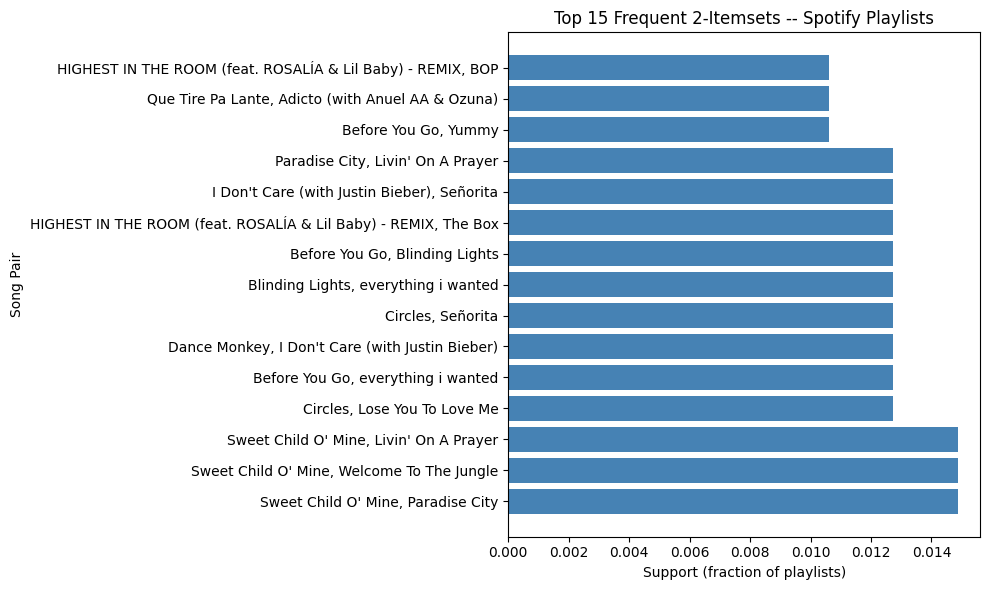

In [50]:
freq2 = freq_items[freq_items['length'] == 2].copy()

labels = []
for items in freq2['itemsets']:
    label = ', '.join(items)
    labels.append(label)

freq2['label'] = labels

top_freq2 = freq2.sort_values(by='support', ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(top_freq2['label'], top_freq2['support'], color='steelblue')
plt.xlabel('Support (fraction of playlists)')
plt.ylabel('Song Pair')
plt.title('Top 15 Frequent 2-Itemsets -- Spotify Playlists')
plt.tight_layout()
plt.show()

#### Visualization of Frequent 3-itemsets

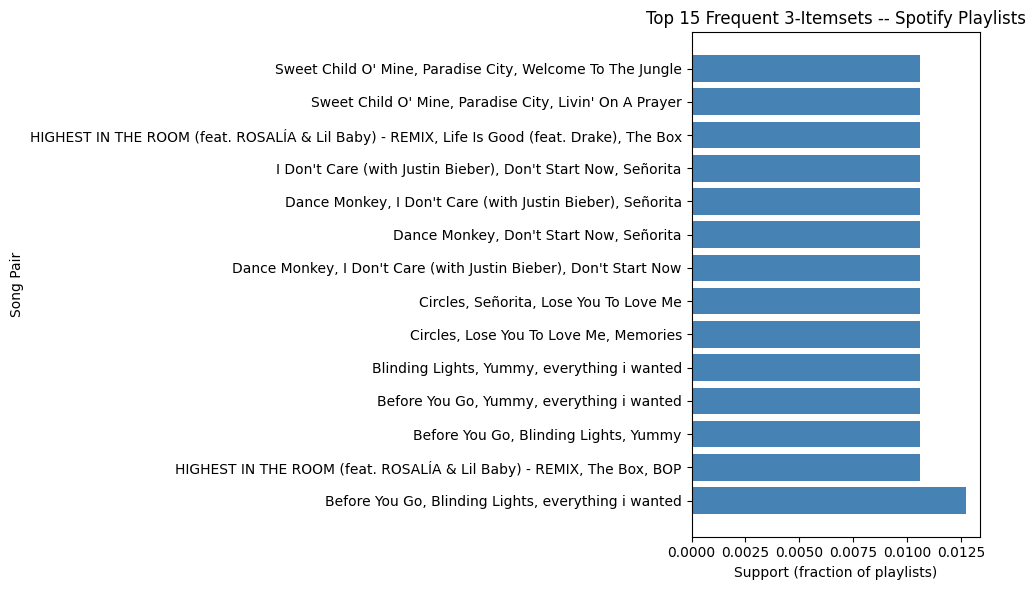

In [51]:
freq3 = freq_items[freq_items['length'] == 3].copy()

labels = []
for items in freq3['itemsets']:
    label = ', '.join(items)
    labels.append(label)

freq3['label'] = labels

top_freq3 = freq3.sort_values(by='support', ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(top_freq3['label'], top_freq3['support'], color='steelblue')
plt.xlabel('Support (fraction of playlists)')
plt.ylabel('Song Pair')
plt.title('Top 15 Frequent 3-Itemsets -- Spotify Playlists')
plt.tight_layout()
plt.show()

### Interpretation 
Based on the top 10 frequent itemsets, songs like “Breathe,” “Poison,” “Alive,” “Forever,” and “Paradise” have the highest support (~3–4%). These would be "safe" picks if there is no existing knowledge about a user, but are not informative of the relationships between songs. The generated top 10 association rules have high confidence and high lift, indicating songs that are tightly linked (in the same playlist, by the same artist, or part of a listening pattern). Since the dataset is large and sparse, the support is often small. However, within this dataset, these rules are strong.